In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load Data**

In [2]:
df = pd.read_csv("/content/15_9-23.csv")
df.head(5)

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0
3,15/9-23,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,NaN,...,125.159531,334.233185,1.663353,0.024972,NaN,NaN,98.923820,NaN,65000,3.0
4,15/9-23,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,NaN,0.849849,...,107.576691,330.952362,0.989743,0.024527,NaN,NaN,102.242142,NaN,65000,3.0


In [3]:
litho_map = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    88000: 'Halite',
    86000: 'Anhydrite',
    99000: 'Tuff',
    90000: 'Coal'
}

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11063 entries, 0 to 11062
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   WELL                               11063 non-null  object 
 1   DEPTH_MD                           11063 non-null  float64
 2   X_LOC                              11063 non-null  float64
 3   Y_LOC                              11063 non-null  float64
 4   Z_LOC                              11063 non-null  float64
 5   GROUP                              11063 non-null  object 
 6   FORMATION                          11063 non-null  object 
 7   CALI                               11063 non-null  float64
 8   RSHA                               0 non-null      float64
 9   RMED                               11009 non-null  float64
 10  RDEP                               11063 non-null  float64
 11  RHOB                               11009 non-null  flo

**Data Cleaning**

In [5]:
df1 = df[["WELL","DEPTH_MD","GROUP","CALI","RDEP","RHOB","GR","NPHI","PEF","DTC","FORCE_2020_LITHOFACIES_LITHOLOGY"]].copy()
df1["LITH"] = df1["FORCE_2020_LITHOFACIES_LITHOLOGY"].map(litho_map)
df1 = df1.drop("FORCE_2020_LITHOFACIES_LITHOLOGY", axis=1)
df2=df1.copy()
df2

,WELL,DEPTH_MD,GROUP,CALI,RDEP,RHOB,GR,NPHI,PEF,DTC,LITH
0,15/9-23,1518.280,HORDALAND GP.,15.506232,0.878615,NaN,103.451515,0.439925,NaN,147.043427,Shale
1,15/9-23,1518.432,HORDALAND GP.,18.524611,0.874237,NaN,94.124893,0.504055,NaN,145.426468,Shale
2,15/9-23,1518.584,HORDALAND GP.,18.855669,0.869858,NaN,93.586487,0.512960,NaN,145.295105,Shale
3,15/9-23,1518.736,HORDALAND GP.,19.163353,0.865479,NaN,91.113373,0.500070,NaN,143.657593,Shale
4,15/9-23,1518.888,HORDALAND GP.,18.489744,0.863804,NaN,100.228333,0.277670,NaN,142.838440,Shale
...,...,...,...,...,...,...,...,...,...,...,...
11058,15/9-23,3212.016,VESTLAND GP.,8.622439,2.660877,2.662135,59.231411,NaN,6.211904,NaN,Sandstone
11059,15/9-23,3212.168,VESTLAND GP.,8.654653,1.651926,2.574645,68.286255,NaN,5.445361,NaN,Sandstone/Shale
11060,15/9-23,3212.320,VESTLAND GP.,8.596466,1.310661,2.484784,85.151917,NaN,5.160233,NaN,Sandstone/Shale
11061,15/9-23,3212.472,VESTLAND GP.,8.673164,1.262026,2.483438,94.557449,NaN,5.000957,NaN,Shale


**Check Null**

In [6]:
df3 = (df2.isnull().sum() / len(df2))*100
df3[df3>0]

,0
RHOB,0.488114
NPHI,0.235018
PEF,2.042846
DTC,1.102775


**Null Imputation**

In [7]:
from sklearn.impute import KNNImputer
logs = ['RHOB', 'NPHI', 'PEF', 'DTC']
imputer = KNNImputer(n_neighbors=5)
df2[logs] = imputer.fit_transform(df2[logs])
df3 = df2.copy()

**Visualize The Target Data**

<Axes: xlabel='LITH'>

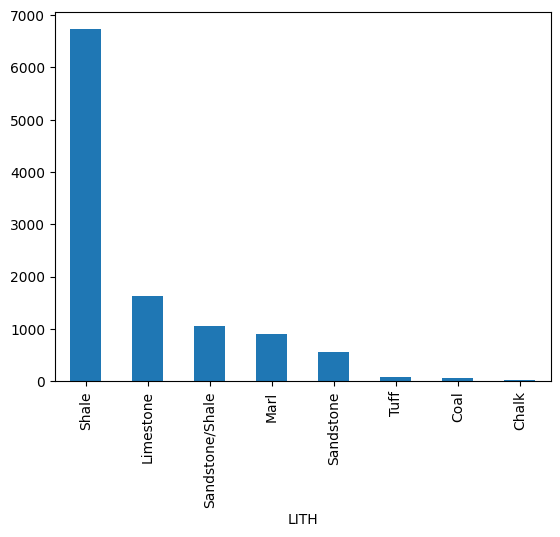

In [9]:
df3.LITH.value_counts().plot.bar()

**Train and Split Data**

In [54]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [55]:
X = df3[['CALI', 'RDEP', 'RHOB', 'GR', 'NPHI','PEF', 'DTC']]
y = df3['LITH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [56]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

**Baseline Model**

In [57]:
#build the model
models ={"Random Forest": RandomForestClassifier(n_estimators=300),
        "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05),}


────────────────────────────────────────
Model : Random Forest
Train acc : 1.0000
Test acc : 0.9563
                 precision    recall  f1-score   support

          Chalk       1.00      0.44      0.62         9
           Coal       0.95      0.95      0.95        19
      Limestone       0.95      0.92      0.93       489
           Marl       0.87      0.92      0.90       274
      Sandstone       0.91      0.87      0.89       169
Sandstone/Shale       0.88      0.90      0.89       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.84      0.73      0.78        22

       accuracy                           0.96      3319
      macro avg       0.92      0.84      0.87      3319
   weighted avg       0.96      0.96      0.96      3319



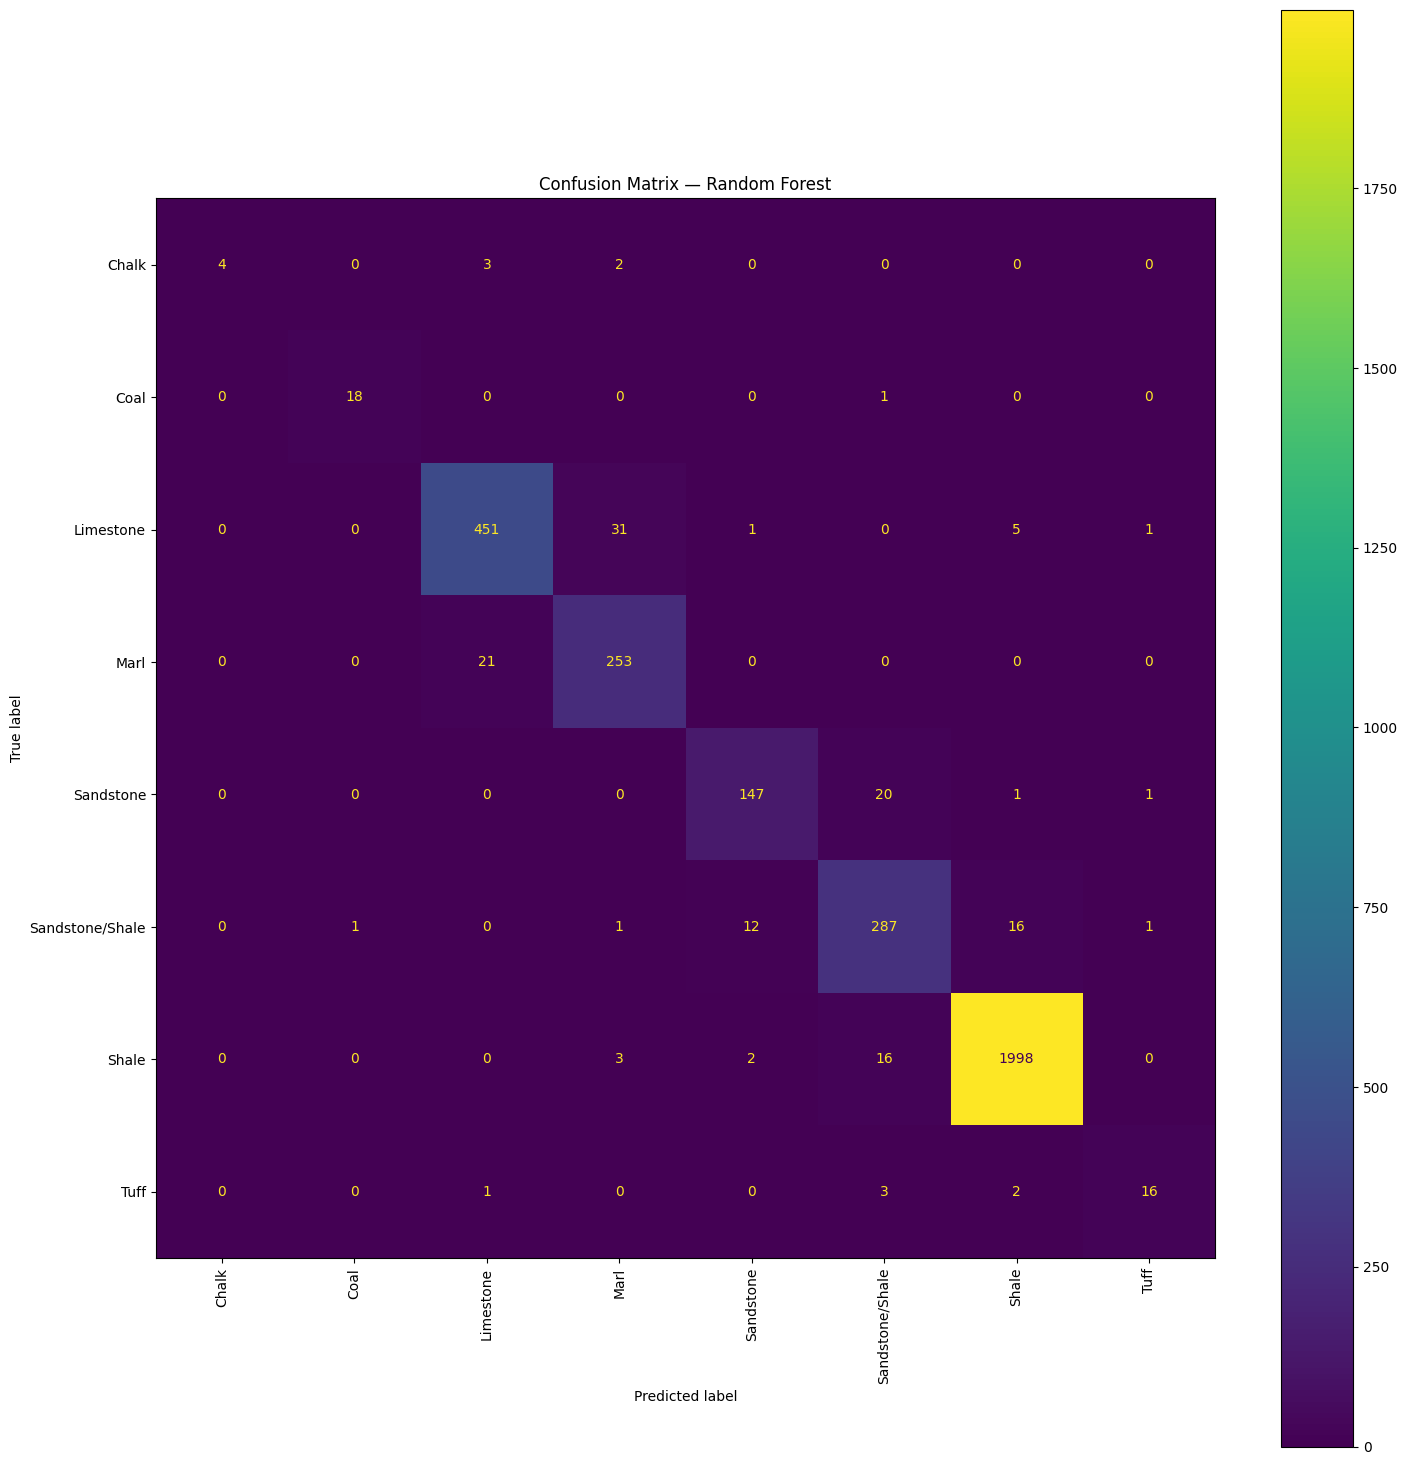


────────────────────────────────────────
Model : XGBoost
Train acc : 0.9997
Test acc : 0.9557
                 precision    recall  f1-score   support

          Chalk       1.00      0.56      0.71         9
           Coal       0.86      0.95      0.90        19
      Limestone       0.95      0.93      0.94       489
           Marl       0.88      0.92      0.90       274
      Sandstone       0.89      0.88      0.88       169
Sandstone/Shale       0.87      0.89      0.88       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.90      0.82      0.86        22

       accuracy                           0.96      3319
      macro avg       0.92      0.87      0.88      3319
   weighted avg       0.96      0.96      0.96      3319



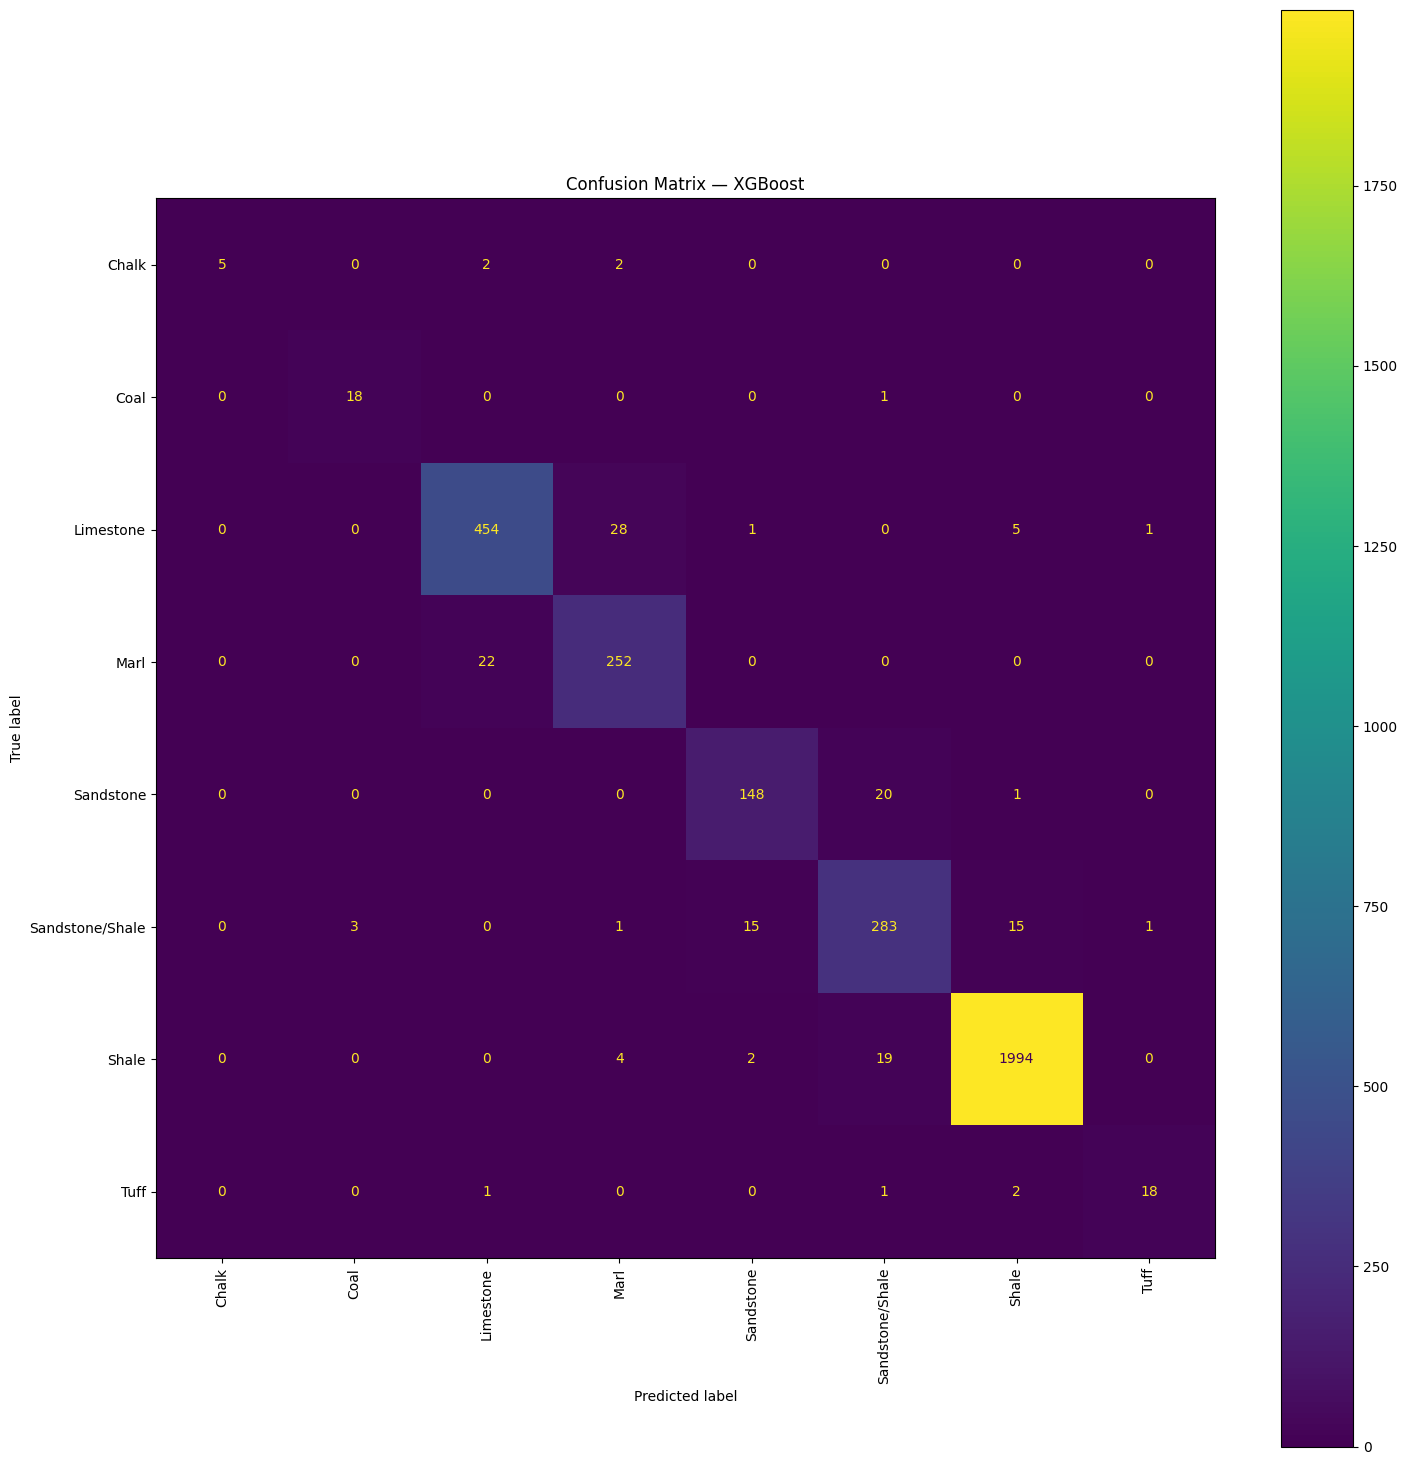


Summary
         Model  Train_acc  Test_acc
Random Forest   1.000000  0.956312
      XGBoost   0.999742  0.955710


In [58]:
results = []

for name, model in models.items():
    # ── fit ──────────────────────────────────────────────
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_train_true, y_test_true = y_train_enc, y_test_enc
        class_names = le.classes_
    else: # Random Forest
        model.fit(X_train, y_train)
        y_train_true, y_test_true = y_train, y_test
        class_names = model.classes_

    # ── predict ──────────────────────────────────────────
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ── accuracy ─────────────────────────────────────────
    train_acc = accuracy_score(y_train_true, y_train_pred)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    results.append([name, train_acc, test_acc])

    # ── detailed evaluation (inline, no separate function) ─
    print(f"\n{'─'*40}")
    print(f"Model : {name}")
    print(f"Train acc : {train_acc:.4f}")
    print(f"Test acc : {test_acc:.4f}")
    print(classification_report(y_test_true, y_test_pred, target_names=class_names))

    # ── confusion matrix ─────────────────────────────────
    cm  = confusion_matrix(y_test_true, y_test_pred, labels=list(range(len(class_names))) if name == "XGBoost" else class_names)
    cmd = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(15, 15))
    cmd.plot(ax=ax)
    plt.xticks(rotation=90)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# ── summary table ────────────────────────────────────────
results_df = pd.DataFrame(results, columns=["Model", "Train_acc", "Test_acc"])
print("\nSummary\n", results_df.to_string(index=False))

**Hyperparameter Tuning**

In [73]:
from sklearn.model_selection import GridSearchCV

In [74]:
# 1. Define parameter grids
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

xgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

In [75]:
# 2. Initialize GridSearchCV — use f1_weighted, not r2
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

In [76]:
#build the model
models_hyp ={"Random Forest": rf_grid,
        "XGBoost": xgb_grid}

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

────────────────────────────────────────
Model     : Random Forest
Train acc : 0.9982
Test acc  : 0.9557
                 precision    recall  f1-score   support

          Chalk       1.00      0.44      0.62         9
           Coal       0.94      0.89      0.92        19
      Limestone       0.95      0.92      0.94       489
           Marl       0.87      0.93      0.90       274
      Sandstone       0.90      0.86      0.88       169
Sandstone/Shale       0.87      0.90      0.89       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.85      0.77      0.81        22

       accuracy                           0.96      3319
      macro avg       0.92      0.84      0.87      3319
   weighted avg       0.96      0.96      0.96      3319



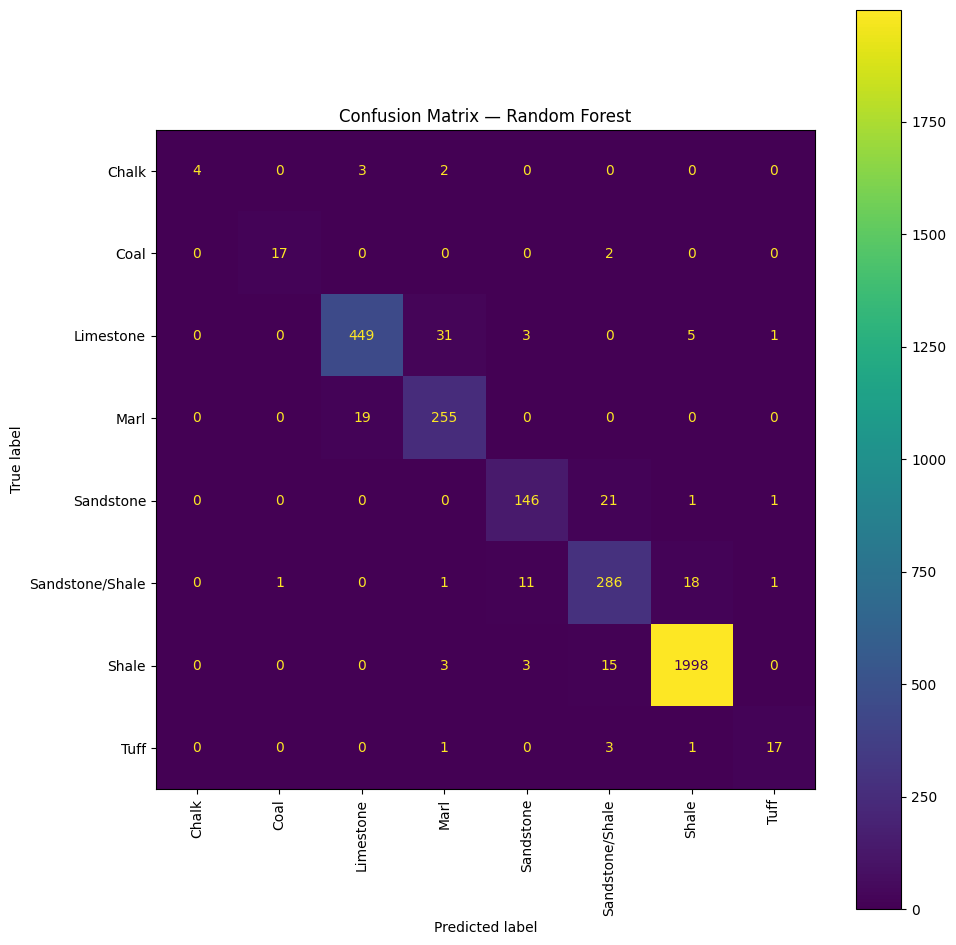

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params for XGBoost: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

────────────────────────────────────────
Model     : XGBoost
Train acc : 0.9997
Test acc  : 0.9572
                 precision    recall  f1-score   support

          Chalk       1.00      0.56      0.71         9
           Coal       0.86      0.95      0.90        19
      Limestone       0.95      0.92      0.94       489
           Marl       0.88      0.93      0.90       274
      Sandstone       0.90      0.88      0.89       169
Sandstone/Shale       0.88      0.89      0.89       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.90      0.82      0.86        22

       accuracy                           0.96      3319
      macro avg       0.92      0.87      0.88      3319
   weighted avg       0.96      0.96      0.96      3319



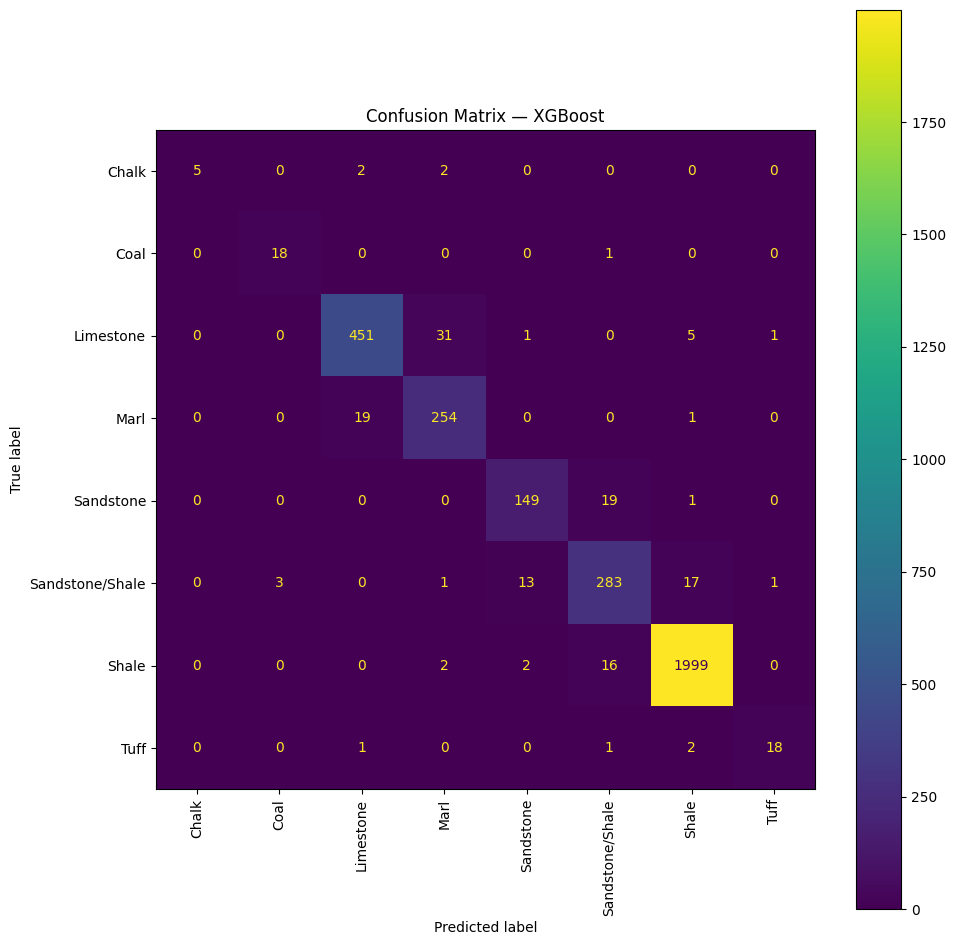


Summary
         Model  Train_acc  Test_acc
Random Forest   0.998192  0.955710
      XGBoost   0.999742  0.957216


In [79]:
results = []
for name, model in models_hyp.items():

    # Determine the target labels to use for fitting and evaluation
    if name == "XGBoost":
        fit_y = y_train_enc
        eval_y_train = y_train_enc
        eval_y_test = y_test_enc
        class_names = le.classes_
    else: # Random Forest
        fit_y = y_train
        eval_y_train = y_train
        eval_y_test = y_test
        # class_names will be set after fitting for RandomForest

    # ── fit ──────────────────────────────────────────────
    model.fit(X_train, fit_y)

    # Set class_names after fitting for RandomForest as best_estimator_ is available
    if name == "Random Forest":
        class_names = model.best_estimator_.classes_

    print(f"\nBest params for {name}: {model.best_params_}")

    # ── predict ───────────────────────────────────────────
    y_train_pred = model.predict(X_train)
    y_test_pred   = model.predict(X_test)

    # ── accuracy ──────────────────────────────────────────
    train_acc = accuracy_score(eval_y_train, y_train_pred)
    test_acc  = accuracy_score(eval_y_test,  y_test_pred)
    results.append([name, train_acc, test_acc])

    # ── report ────────────────────────────────────────────
    print(f"\n{'─'*40}")
    print(f"Model     : {name}")
    print(f"Train acc : {train_acc:.4f}")
    print(f"Test acc  : {test_acc:.4f}")
    print(classification_report(eval_y_test, y_test_pred, target_names=class_names))

    # ── confusion matrix ──────────────────────────────────
    # For XGBoost, confusion_matrix expects numerical labels if eval_y_test was numerical.
    # For RandomForest, it expects string labels if eval_y_test was string.
    # The labels argument in confusion_matrix should be consistent with the data provided.
    cm  = confusion_matrix(eval_y_test, y_test_pred, labels=list(range(len(class_names))) if name == "XGBoost" else class_names)
    cmd = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    cmd.plot(ax=ax)
    plt.xticks(rotation=90)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# ── summary table ─────────────────────────────────────────
results_df = pd.DataFrame(results, columns=["Model", "Train_acc", "Test_acc"])
print("\nSummary\n", results_df.to_string(index=False))

In [80]:
from sklearn.utils import compute_class_weight
class_labels = df3.LITH.unique()
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=df3.LITH)

In [81]:
weights

array([ 0.20544867,  1.30459906,  0.84838957,  2.4562611 , 18.6875    ,
       47.68534483,  1.51631031, 21.60742188])

In [82]:
class_labels

array(['Shale', 'Sandstone/Shale', 'Limestone', 'Sandstone', 'Tuff',
       'Chalk', 'Marl', 'Coal'], dtype=object)

In [83]:
class_weights = {class_labels[i]: weights[i] for i in range(len(class_labels))}

In [84]:
models_2 ={"Random Forest": RandomForestClassifier(n_estimators=300, class_weight=class_weights),
        "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, class_weight=class_weights)}


────────────────────────────────────────
Model : Random Forest
Train acc : 1.0000
Test acc : 0.9554
                 precision    recall  f1-score   support

          Chalk       1.00      0.44      0.62         9
           Coal       0.94      0.89      0.92        19
      Limestone       0.95      0.92      0.93       489
           Marl       0.88      0.92      0.90       274
      Sandstone       0.91      0.86      0.88       169
Sandstone/Shale       0.87      0.91      0.89       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.89      0.73      0.80        22

       accuracy                           0.96      3319
      macro avg       0.93      0.83      0.87      3319
   weighted avg       0.96      0.96      0.96      3319



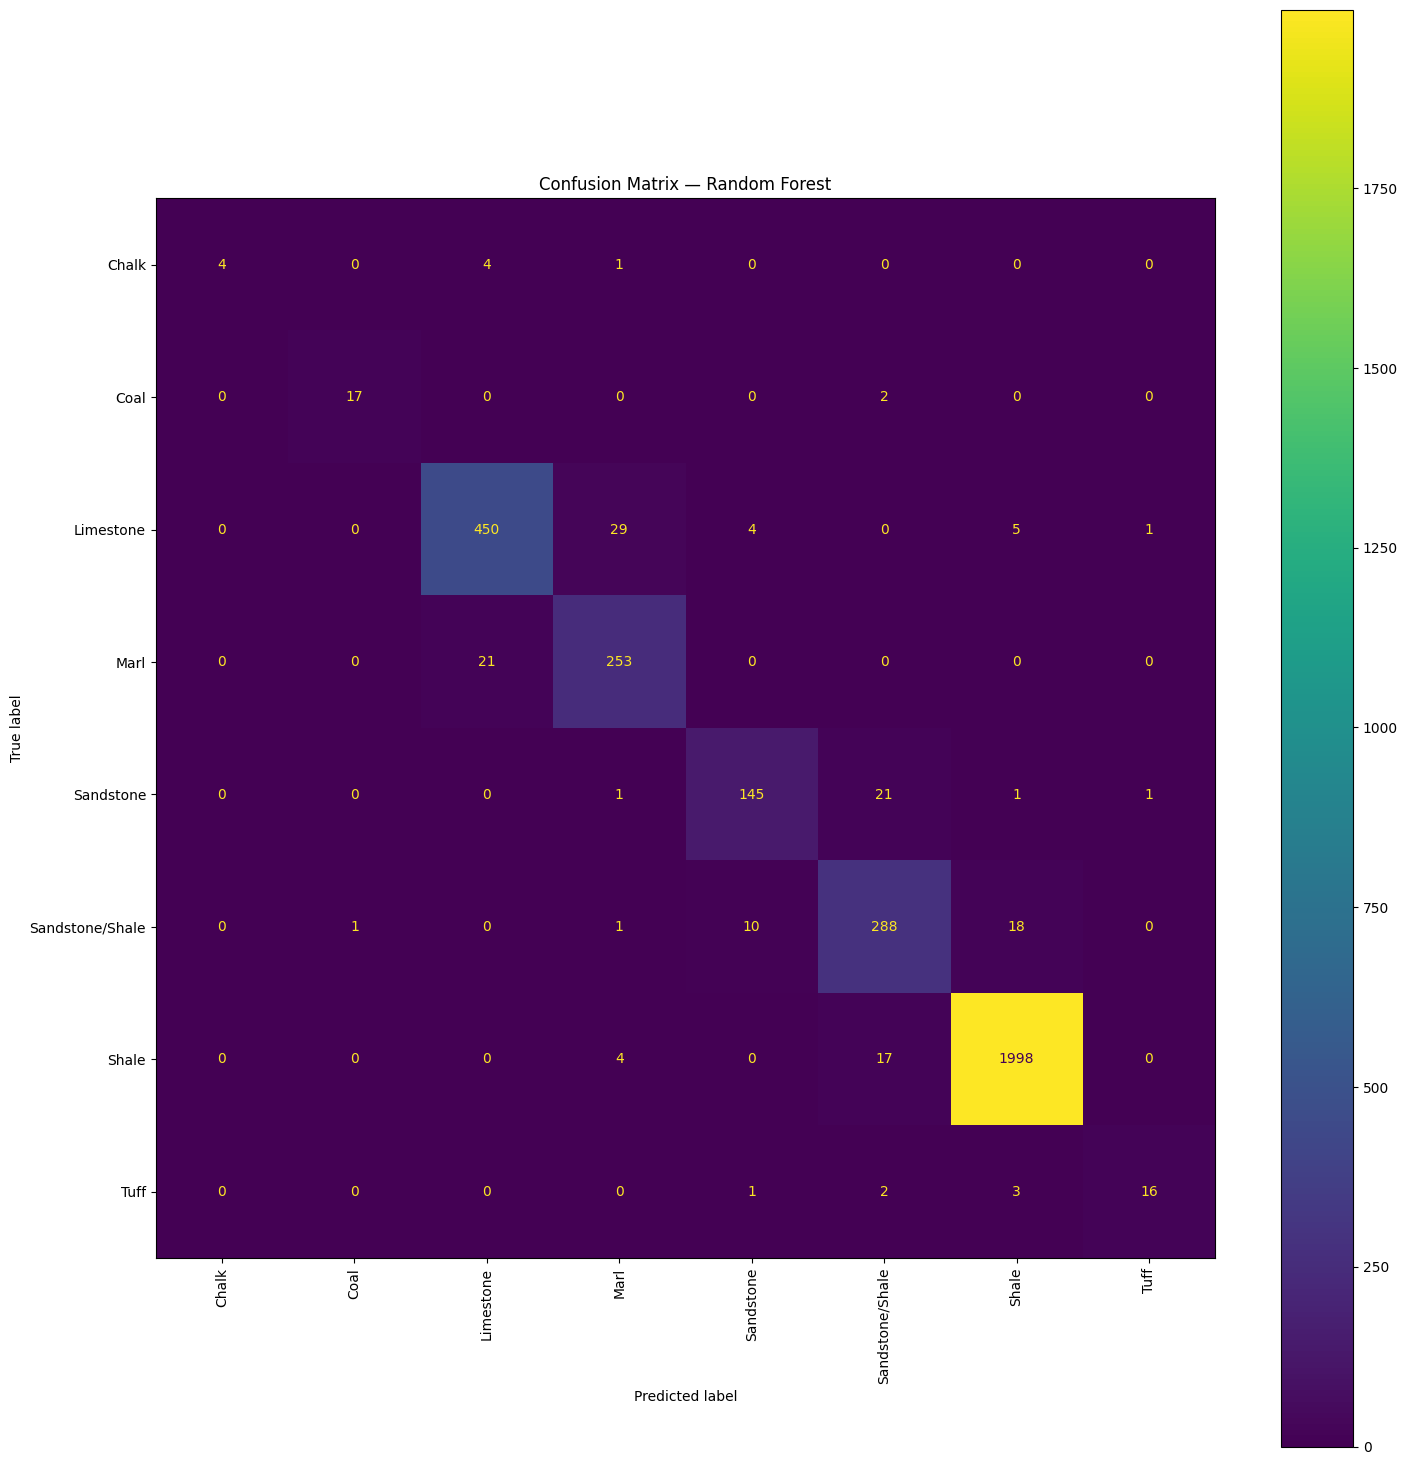

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:47:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



────────────────────────────────────────
Model : XGBoost
Train acc : 0.9997
Test acc : 0.9557
                 precision    recall  f1-score   support

          Chalk       1.00      0.56      0.71         9
           Coal       0.86      0.95      0.90        19
      Limestone       0.95      0.93      0.94       489
           Marl       0.88      0.92      0.90       274
      Sandstone       0.89      0.88      0.88       169
Sandstone/Shale       0.87      0.89      0.88       318
          Shale       0.99      0.99      0.99      2019
           Tuff       0.90      0.82      0.86        22

       accuracy                           0.96      3319
      macro avg       0.92      0.87      0.88      3319
   weighted avg       0.96      0.96      0.96      3319



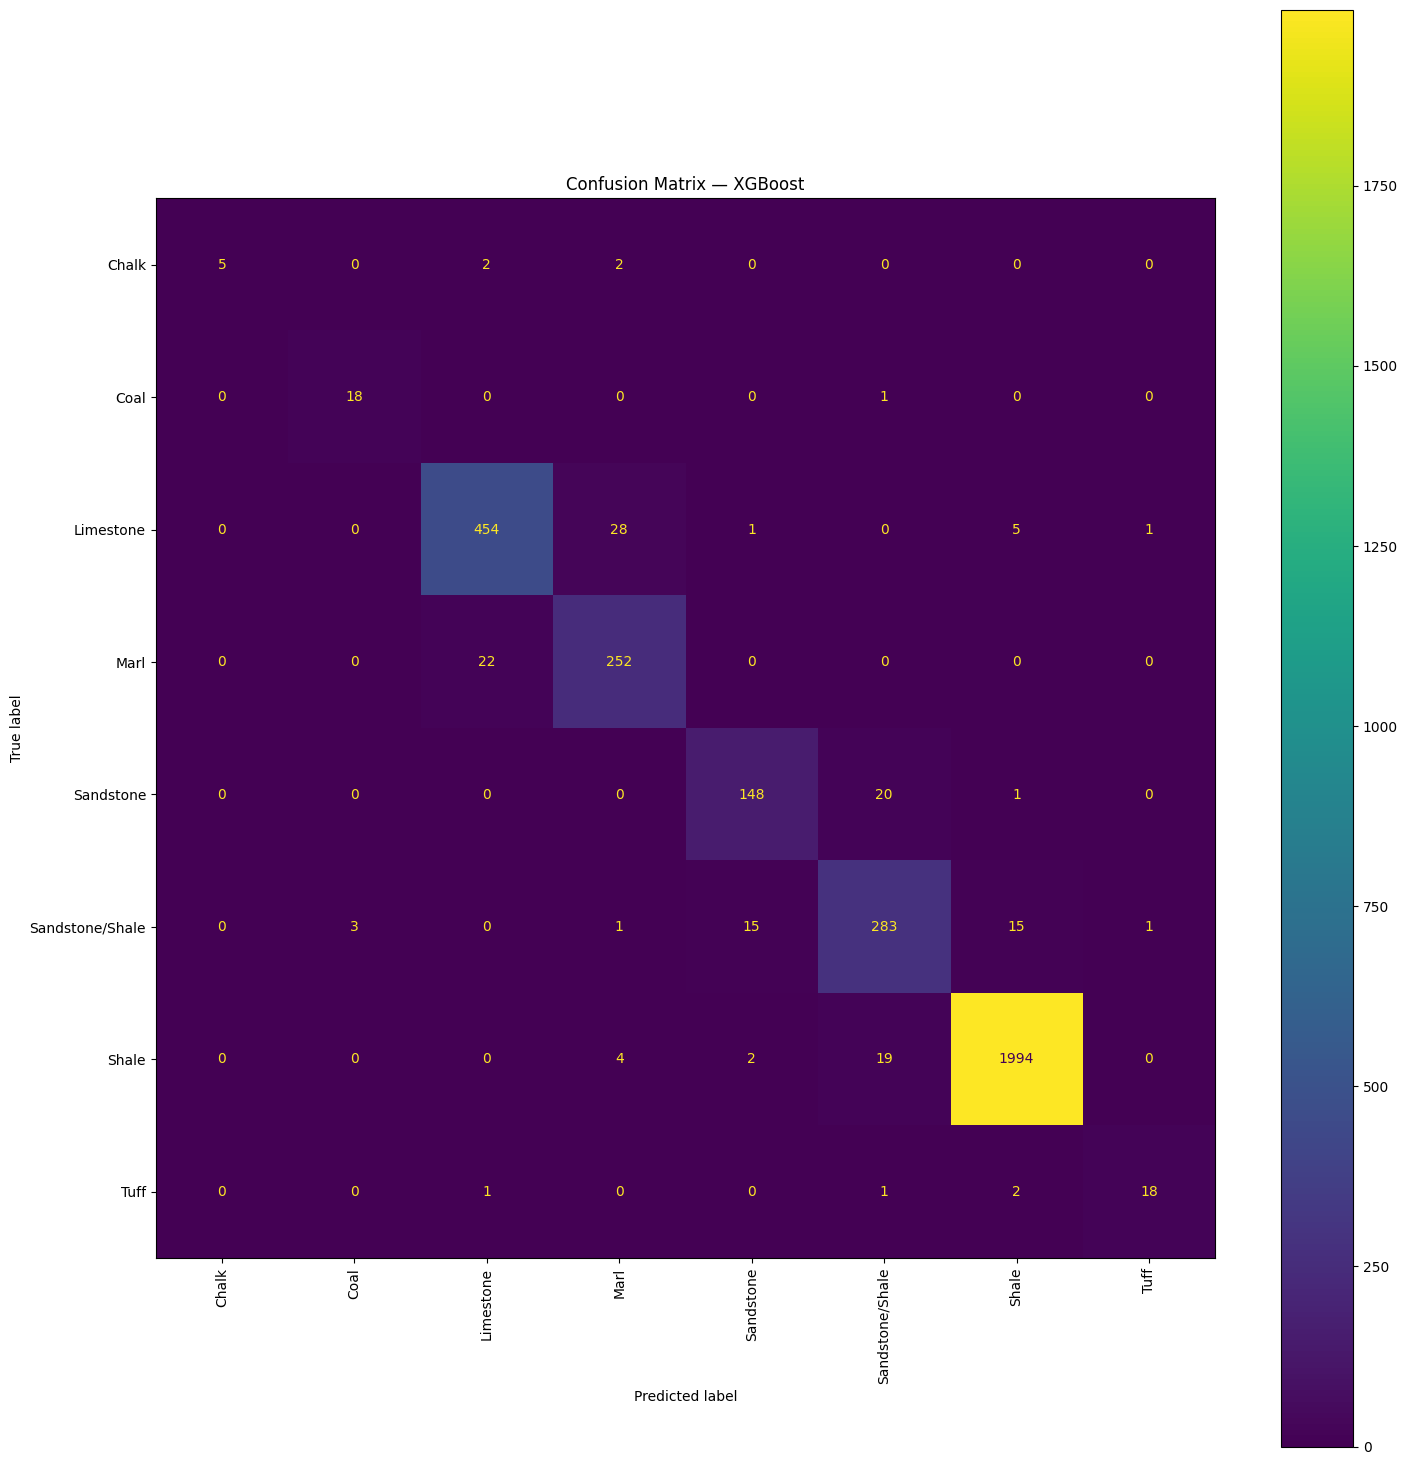


Summary
         Model  Train_acc  Test_acc
Random Forest   1.000000  0.955408
      XGBoost   0.999742  0.955710


In [85]:
results = []

for name, model in models_2.items():
    # ── fit ──────────────────────────────────────────────
    if name == "XGBoost":
        model.fit(X_train, y_train_enc)
        y_train_true, y_test_true = y_train_enc, y_test_enc
        class_names = le.classes_
    else: # Random Forest
        model.fit(X_train, y_train)
        y_train_true, y_test_true = y_train, y_test
        class_names = model.classes_

    # ── predict ──────────────────────────────────────────
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ── accuracy ─────────────────────────────────────────
    train_acc = accuracy_score(y_train_true, y_train_pred)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    results.append([name, train_acc, test_acc])

    # ── detailed evaluation (inline, no separate function) ─
    print(f"\n{'─'*40}")
    print(f"Model : {name}")
    print(f"Train acc : {train_acc:.4f}")
    print(f"Test acc : {test_acc:.4f}")
    print(classification_report(y_test_true, y_test_pred, target_names=class_names))

    # ── confusion matrix ─────────────────────────────────
    cm  = confusion_matrix(y_test_true, y_test_pred, labels=list(range(len(class_names))) if name == "XGBoost" else class_names)
    cmd = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(15, 15))
    cmd.plot(ax=ax)
    plt.xticks(rotation=90)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

# ── summary table ────────────────────────────────────────
results_df = pd.DataFrame(results, columns=["Model", "Train_acc", "Test_acc"])
print("\nSummary\n", results_df.to_string(index=False))